# Frame Co-occurrence Analysis

Analyzing which frames appear together in articles, globally and by media outlet.

In [1]:
!pip install pandas numpy matplotlib seaborn pyarrow

zsh:1: command not found: pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

In [3]:
df = pd.read_parquet('../data/merged_topic_and_frames_filtered.parquet')
print(f'Loaded {len(df):,} articles')

frames = sorted(['economic', 'fairness', 'public_op', 'political', 'quality_life',
                 'crime', 'culture', 'health', 'legality', 'morality',
                 'policy', 'regulation', 'security', 'cap&res'])

frame_matrix = np.array(df['vector'].tolist())

Loaded 80,783 articles


## Global Frame Co-occurrence

In [4]:
cooccur = frame_matrix.T @ frame_matrix

pairs = []
for i, j in combinations(range(len(frames)), 2):
    pairs.append({
        'frame_1': frames[i],
        'frame_2': frames[j],
        'count': cooccur[i, j],
        'rate': cooccur[i, j] / len(df)
    })

pairs_df = pd.DataFrame(pairs).sort_values('count', ascending=False)
print('Top 10 co-occurring frame pairs:')
pairs_df.head(10)

Top 10 co-occurring frame pairs:


,frame_1,frame_2,count,rate
64,legality,policy,32545,0.402869
47,fairness,legality,23400,0.289665
17,crime,legality,22738,0.281470
78,policy,quality_life,20467,0.253358
69,legality,security,18728,0.231831
40,economic,policy,16873,0.208868
49,fairness,policy,16756,0.207420
65,legality,political,15530,0.192243
68,legality,regulation,13791,0.170717
80,policy,security,13699,0.169578


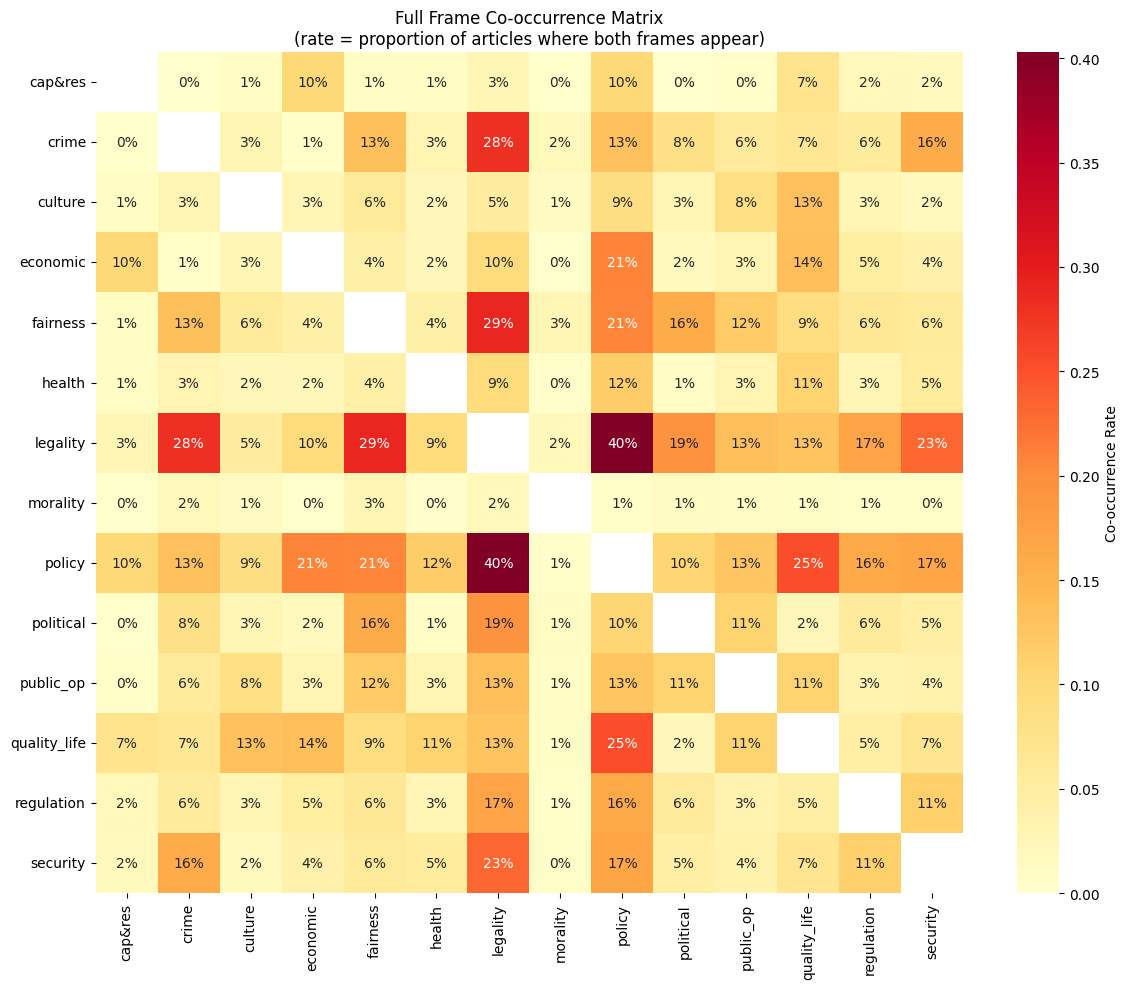

In [5]:
# Full co-occurrence matrix heatmap
cooccur_rate = cooccur / len(df)
cooccur_df = pd.DataFrame(cooccur_rate, index=frames, columns=frames)

# Mask the diagonal (self-co-occurrence) for clearer visualization
mask = np.eye(len(frames), dtype=bool)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cooccur_df, annot=True, fmt='.0%', cmap='YlOrRd', ax=ax, mask=mask,
            cbar_kws={'label': 'Co-occurrence Rate'})
plt.title('Full Frame Co-occurrence Matrix\n(rate = proportion of articles where both frames appear)')
plt.tight_layout()
plt.show()

## Frame Co-occurrence by Media Outlet

In [6]:
print('Articles per outlet:')
print(df['outlet_name'].value_counts())

Articles per outlet:
outlet_name
Newsweek               21579
Breitbart News         14671
HuffPost                9617
New York Post           8424
CNBC                    7957
Reuters                 6979
Washington Times        6579
The Washington Post     2770
BBC News                2207
Name: count, dtype: int64


In [7]:
top_pairs = pairs_df.head(5)

comparison = []
for outlet in df['outlet_name'].unique():
    subset = df[df['outlet_name'] == outlet]
    mat = np.array(subset['vector'].tolist())
    outlet_cooccur = mat.T @ mat
    
    row = {'outlet': outlet, 'n_articles': len(subset)}
    for _, pair in top_pairs.iterrows():
        i, j = frames.index(pair['frame_1']), frames.index(pair['frame_2'])
        pair_name = f"{pair['frame_1']}-{pair['frame_2']}"
        row[pair_name] = outlet_cooccur[i, j] / len(subset)
    comparison.append(row)

comparison_df = pd.DataFrame(comparison).sort_values('n_articles', ascending=False)
comparison_df

,outlet,n_articles,legality-policy,fairness-legality,crime-legality,policy-quality_life,legality-security
1,Newsweek,21579,0.406831,0.313314,0.344316,0.241809,0.281060
7,Breitbart News,14671,0.448913,0.428532,0.398405,0.085952,0.311499
0,HuffPost,9617,0.261828,0.258917,0.181657,0.319746,0.108350
6,New York Post,8424,0.298670,0.259853,0.340100,0.248932,0.181861
4,CNBC,7957,0.425789,0.120397,0.072138,0.534749,0.153073
5,Reuters,6979,0.551368,0.162058,0.149305,0.237713,0.290873
8,Washington Times,6579,0.513604,0.389725,0.372245,0.185591,0.263110
2,The Washington Post,2770,0.340072,0.294585,0.182671,0.238989,0.138628
3,BBC News,2207,0.266878,0.092433,0.126869,0.461713,0.070684


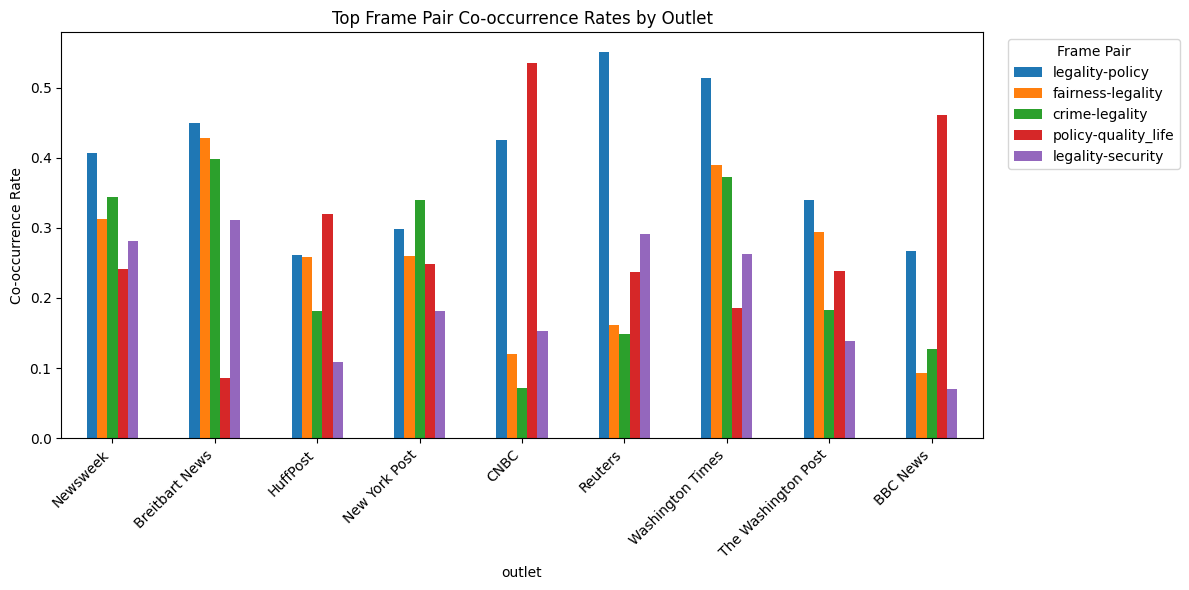

In [8]:
pair_cols = [c for c in comparison_df.columns if '-' in c]

fig, ax = plt.subplots(figsize=(12, 6))
comparison_df.set_index('outlet')[pair_cols].plot(kind='bar', ax=ax)
plt.title('Top Frame Pair Co-occurrence Rates by Outlet')
plt.ylabel('Co-occurrence Rate')
plt.legend(title='Frame Pair', bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
print('Co-occurrence rate ranges across outlets:\n')
for col in pair_cols:
    vals = comparison_df[col]
    print(f'{col}: {vals.min():.0%} - {vals.max():.0%} (range: {vals.max()-vals.min():.0%})')

Co-occurrence rate ranges across outlets:

legality-policy: 26% - 55% (range: 29%)
fairness-legality: 9% - 43% (range: 34%)
crime-legality: 7% - 40% (range: 33%)
policy-quality_life: 9% - 53% (range: 45%)
legality-security: 7% - 31% (range: 24%)
